In [1]:
from pathlib import Path

# Проверка директорий
img_dir = Path('visualization_results_2')
raw_dir = Path('thicks_export_2')

print(f"📁 Директория изображений: {img_dir.absolute()}")
print(f"   Существует: {img_dir.exists()}")
if img_dir.exists():
    files = list(img_dir.iterdir())
    print(f"   Файлов в директории: {len(files)}")
    # Показываем первые 5 файлов
    for f in files[:5]:
        print(f"   - {f.name}")
else:
    print("   ❌ ДИРЕКТОРИЯ НЕ НАЙДЕНА!")

print(f"\n📁 Директория RAW: {raw_dir.absolute()}")
print(f"   Существует: {raw_dir.exists()}")
if raw_dir.exists():
    raw_files = list(raw_dir.glob('*.raw'))
    print(f"   .raw файлов: {len(raw_files)}")
else:
    print("   ❌ ДИРЕКТОРИЯ НЕ НАЙДЕНА!")

📁 Директория изображений: D:\Универ\ВКР\Код\ПарсингДаных\DataTransform\scientificProject\visualization_results_2
   Существует: True
   Файлов в директории: 3510
   - thick_378463.png
   - thick_378464.png
   - thick_378465.png
   - thick_378466.png
   - thick_378467.png

📁 Директория RAW: D:\Универ\ВКР\Код\ПарсингДаных\DataTransform\scientificProject\thicks_export_2
   Существует: True
   .raw файлов: 3506


In [2]:
# ВАЖНО: Настройка matplotlib для Jupyter
%matplotlib widget
# Или если не работает:
# %matplotlib inline

import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets

Найдено файлов: 3510
Первый файл: thick_378463.png
Полный путь: D:\Универ\ВКР\Код\ПарсингДаных\DataTransform\scientificProject\visualization_results_2\thick_378463.png
Существует: True

Попытка отображения...


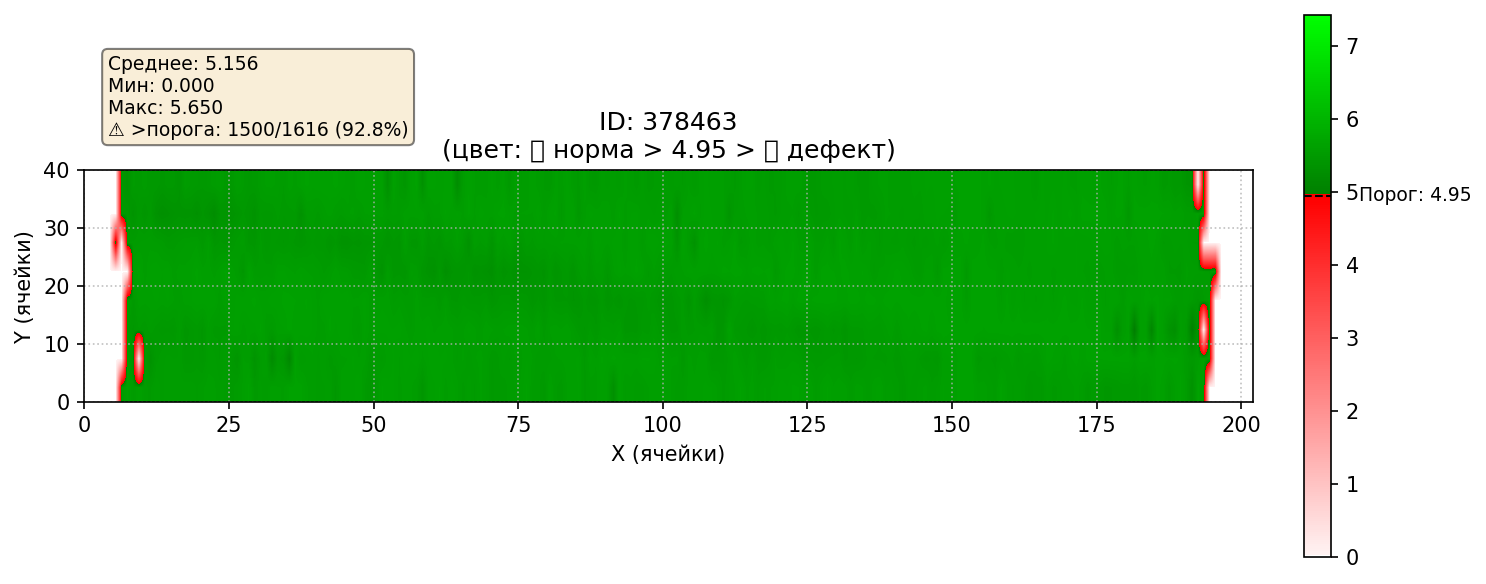

✓ Если видите изображение выше — работает!


In [4]:
from pathlib import Path
from IPython.display import display, Image

# Проверяем первый файл
img_dir = Path('visualization_results_2')
files = list(img_dir.glob('*.png'))

print(f"Найдено файлов: {len(files)}")
if files:
    print(f"Первый файл: {files[0].name}")
    print(f"Полный путь: {files[0].absolute()}")
    print(f"Существует: {files[0].exists()}")
    
    # Пробуем показать
    print("\nПопытка отображения...")
    display(Image(filename=str(files[0])))
    print("✓ Если видите изображение выше — работает!")
else:
    print("❌ Файлы не найдены")

Загрузка visualization_results_2\thick_378463.png...
Размер: (584, 1486, 4)


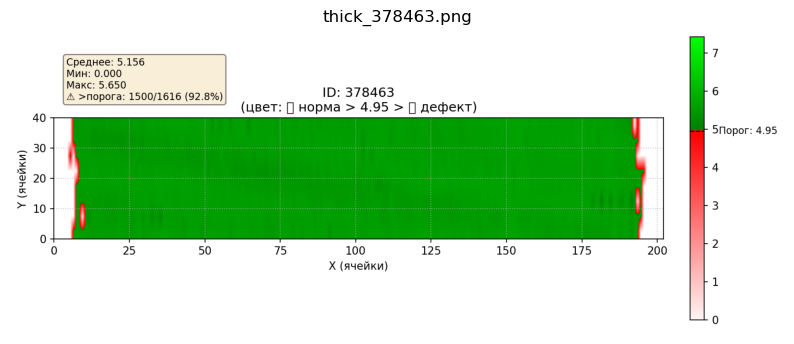

✓ Изображение показано выше


In [5]:
# Альтернативный способ через matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

img_file = Path('visualization_results_2/thick_378463.png')

if img_file.exists():
    print(f"Загрузка {img_file}...")
    img = mpimg.imread(str(img_file))
    print(f"Размер: {img.shape}")
    
    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.title(img_file.name)
    plt.axis('off')
    plt.show()
    print("✓ Изображение показано выше")
else:
    print(f"❌ Файл не найден: {img_file}")

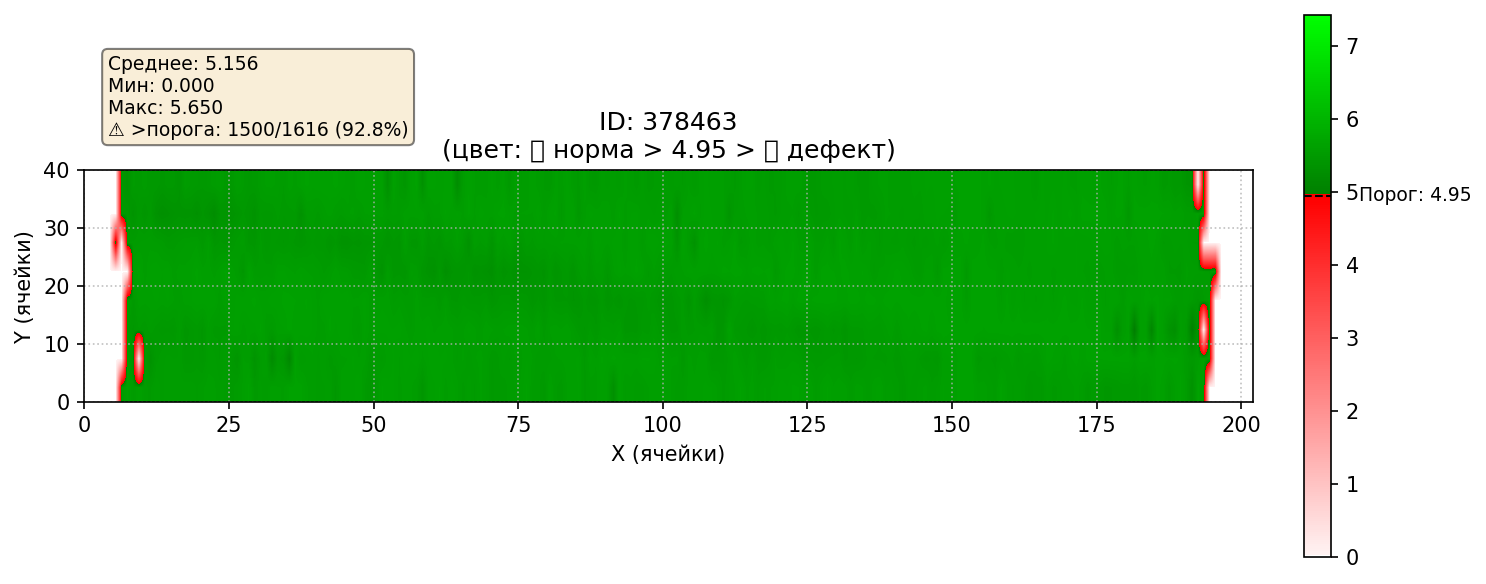

In [6]:
%matplotlib inline
from IPython.display import display, clear_output, Image as IPyImage
from PIL import Image as PILImage
import ipywidgets as widgets
from pathlib import Path
import shutil

class FastLabeler:
    def __init__(self, img_dir, raw_dir, good_dir, bad_dir, start_idx=0):
        self.img_dir = Path(img_dir)
        self.raw_dir = Path(raw_dir)
        self.good_dir = Path(good_dir)
        self.bad_dir = Path(bad_dir)
        
        self.good_dir.mkdir(exist_ok=True)
        self.bad_dir.mkdir(exist_ok=True)
        
        self.files = sorted(self.img_dir.glob('*.png'))
        self.idx = start_idx
        self.history = []
        
        if not self.files:
            print("❌ Не найдено PNG файлов!")
            return

        # Кнопки
        self.btn_good = widgets.Button(description='✅ Годный', button_style='success', layout=widgets.Layout(width='130px'))
        self.btn_bad  = widgets.Button(description='❌ Брак', button_style='danger', layout=widgets.Layout(width='130px'))
        self.btn_skip = widgets.Button(description='⏭ Пропустить', button_style='info', layout=widgets.Layout(width='130px'))
        self.btn_undo = widgets.Button(description='↩ Отмена', button_style='warning', layout=widgets.Layout(width='130px'))
        
        self.btn_good.on_click(self._action_good)
        self.btn_bad.on_click(self._action_bad)
        self.btn_skip.on_click(lambda b: self._next())
        self.btn_undo.on_click(self._undo)
        
        self.controls = widgets.HBox([self.btn_good, self.btn_bad, self.btn_skip, self.btn_undo])
        self.info = widgets.HTML()
        
        display(self.info)
        display(self.controls)
        self._render()

    def _render(self):
        clear_output(wait=True)
        display(self.info)
        display(self.controls)
        
        if self.idx >= len(self.files):
            self.info.value = "<h2 style='color:green;'>✅ Все файлы обработаны!</h2>"
            return
            
        f = self.files[self.idx]
        raw = self.raw_dir / f"{f.stem}.raw"
        pct = (self.idx / len(self.files)) * 100
        
        status = "✅ найден" if raw.exists() else "❌ отсутствует"
        self.info.value = f"""
        <div style='font-family:monospace; font-size:14px; line-height:1.6;'>
            <b>📊 Прогресс:</b> {self.idx+1} / {len(self.files)} ({pct:.1f}%)<br>
            <b>📁 Файл:</b> {f.name}<br>
            <b>📦 .raw:</b> {status}
        </div>
        """
        display(IPyImage(filename=str(f)))

    def _next(self):
        self.idx += 1
        self._render()

    def _action_good(self, b): self._move('good')
    def _action_bad(self, b): self._move('bad')

    def _move(self, label):
        if self.idx >= len(self.files): return
        f = self.files[self.idx]
        raw = self.raw_dir / f"{f.stem}.raw"
        
        if not raw.exists():
            print(f"⚠️ .raw не найден для {f.name}, пропускаем...")
            self._next()
            return
            
        target = self.good_dir if label == 'good' else self.bad_dir
        dst = target / raw.name
        shutil.move(str(raw), str(dst))
        self.history.append({'src': raw, 'dst': dst})
        
        print(f"{'✅' if label=='good' else '❌'} Перемещено: {raw.name}")
        self._next()

    def _undo(self, b):
        if not self.history:
            print("⚠️ История пуста")
            return
        last = self.history.pop()
        shutil.move(str(last['dst']), str(last['src']))
        print(f"↩ Отменено: {last['src'].name}")
        self.idx -= 1
        self._render()

# 🚀 ЗАПУСК
print("⏳ Инициализация...")
labeler = FastLabeler(
    img_dir='visualization_results_2',
    raw_dir='thicks_export_2',
    good_dir='good_samples',
    bad_dir='bad_samples',
    start_idx=0
)

In [7]:
%matplotlib inline
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path
import shutil

class PyCharmFriendlyLabeler:
    def __init__(self, img_dir, raw_dir, good_dir, bad_dir, start_idx=0):
        self.img_dir = Path(img_dir)
        self.raw_dir = Path(raw_dir)
        self.good_dir = Path(good_dir)
        self.bad_dir = Path(bad_dir)
        
        self.good_dir.mkdir(exist_ok=True)
        self.bad_dir.mkdir(exist_ok=True)
        
        self.files = sorted(self.img_dir.glob('*.png'))
        self.idx = start_idx
        self.history = []
        
        if not self.files:
            print("❌ Нет изображений PNG!")
            return

        # Кнопки
        self.btn_good = widgets.Button(description='✅ Годный', button_style='success', layout=widgets.Layout(width='130px'))
        self.btn_bad = widgets.Button(description='❌ Брак', button_style='danger', layout=widgets.Layout(width='130px'))
        self.btn_skip = widgets.Button(description='⏭ Пропустить', button_style='info', layout=widgets.Layout(width='130px'))
        self.btn_undo = widgets.Button(description='↩ Отмена', button_style='warning', layout=widgets.Layout(width='130px'))
        
        self.btn_good.on_click(self._action_good)
        self.btn_bad.on_click(self._action_bad)
        self.btn_skip.on_click(lambda b: self._next())
        self.btn_undo.on_click(self._undo)
        
        self.controls = widgets.HBox([self.btn_good, self.btn_bad, self.btn_skip, self.btn_undo])
        
        # ОДИН HTML-виджет для всего (Инфо + Картинка). Без clear_output!
        self.display_area = widgets.HTML(
            layout=widgets.Layout(border='1px solid #ddd', padding='10px', background='#f9f9f9', min_height='300px')
        )
        
        display(self.display_area)
        display(self.controls)
        
        self._render()

    def _render(self):
        if self.idx >= len(self.files):
            self.display_area.value = "<h2 style='text-align:center; color:green;'>🎉 Разметка завершена!</h2>"
            return
            
        f = self.files[self.idx]
        raw = self.raw_dir / f"{f.stem}.raw"
        raw_status = "✅ .raw найден" if raw.exists() else "❌ .raw ОТСУТСТВУЕТ"
        
        # Формируем путь с прямыми слэшами для HTML (безопасно для Windows)
        img_src = f"{self.img_dir.as_posix()}/{f.name}"
        
        # Обновляем HTML напрямую
        self.display_area.value = f"""
        <div style='font-family: monospace; font-size: 14px; line-height: 1.5;'>
            <b>📊 Прогресс:</b> {self.idx+1} / {len(self.files)}<br>
            <b>📁 Файл:</b> {f.name}<br>
            <b>📦 Статус:</b> {raw_status}<br>
            <hr style='border:0; border-top:1px dashed #ccc; margin:10px 0;'>
            <div style='text-align: center;'>
                <img src="{img_src}" style='max-width:100%; max-height:600px; box-shadow: 2px 2px 5px rgba(0,0,0,0.2); border-radius: 4px;'>
            </div>
        </div>
        """

    def _next(self):
        self.idx += 1
        self._render()

    def _action_good(self, b): self._process('good')
    def _action_bad(self, b): self._process('bad')

    def _process(self, label):
        if self.idx >= len(self.files): return
        f = self.files[self.idx]
        raw = self.raw_dir / f"{f.stem}.raw"
        
        if not raw.exists():
            print(f"⚠️ .raw не найден для {f.name}, пропускаем...")
            self._next()
            return
            
        target = self.good_dir if label == 'good' else self.bad_dir
        dst = target / raw.name
        shutil.move(str(raw), str(dst))
        self.history.append({'src': raw, 'dst': dst})
        
        print(f"{'✅' if label=='good' else '❌'} Перемещено: {f.name}")
        self._next()

    def _undo(self, b):
        if not self.history: return
        last = self.history.pop()
        shutil.move(str(last['dst']), str(last['src']))
        self.idx -= 1
        self._render()
        print("↩ Отменено действие")

# 🚀 ЗАПУСК
print("⏳ Инициализация...")
labeler = PyCharmFriendlyLabeler(
    img_dir='visualization_results_2',
    raw_dir='thicks_export_2',
    good_dir='good_samples',
    bad_dir='bad_samples',
    start_idx=0
)

⏳ Инициализация...


HTML(value='', layout=Layout(border_bottom='1px solid #ddd', border_left='1px solid #ddd', border_right='1px s…